## Let's start the **Segmentation** process!

- Load the necessary libraries and the dataset we constructed in the previous notebook.

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
my_path = "Data"
MASTER_RFM_2016 = pd.read_csv(my_path + '\\MASTER_RFM_2016.csv')
MASTER_RFM_2015 = pd.read_csv(my_path + '\\MASTER_RFM_2015.csv')

- Create NEW variable to identify new customers

In [217]:
# New customer if seniority < 1 year
MASTER_RFM_2016["NEW"] = (MASTER_RFM_2016['SENIORITY_2016'] < 365).astype(int)
MASTER_RFM_2015["NEW"] = (MASTER_RFM_2015['SENIORITY_2015'] < 365).astype(int)

print("New customers 2016:", sum(MASTER_RFM_2016["NEW"]))
print("New customers 2015:", sum(MASTER_RFM_2015["NEW"]))

New customers 2016: 4298
New customers 2015: 3808


In 2016, we have almost 600 more new customers than in 2015.

## Determine thresholds in order to split them in low/medium/high groups
- First method: using **quantiles** (33% and 66%)
- Second method: using **KMeans clustering**

In [221]:
MASTER_RFM_2016[['CUMUL_VALUE', 'RECENCY', 'NB_VISITS']].quantile([0.30, 0.66])

,CUMUL_VALUE,RECENCY,NB_VISITS
0.30,136.0,58.0,1.0
0.66,265.0,151.0,2.0


So we can propose the following thresholds: (it's totally up to you to change the thresholds)

`MONETARY VALUE:`
- **low** if less than 136€
- **medium** if between 136€ and 265€
- **high** if more than 265€

`FREQUENCY:`
- **low** if 1 visits on the period
- **medium** if 2 visit on the period
- **high** if 3 visits or more on the period

`RECENCY:`
- **low** if last purchase more than 151 days ago
- **medium** if last purchase between 58 and 151 days ago
- **high** if last purchase less than 58 days ago

In [225]:
min_recency = 58
max_recency = 151
min_frequency = 1
max_frequency = 3
min_money = 136
max_money = 265

In [226]:
MASTER_RFM_2016["RECENCY_level"] = np.where(
    MASTER_RFM_2016["RECENCY"] > max_recency,  
    'Low',
    np.where(
        MASTER_RFM_2016["RECENCY"] < min_recency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2016["FREQUENCY_level"] =np.where(
    MASTER_RFM_2016["NB_VISITS"] <= min_frequency,  
    'Low',
    np.where(
        MASTER_RFM_2016["NB_VISITS"] >= max_frequency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2016["MONEY_level"] = np.where(
    MASTER_RFM_2016["CUMUL_VALUE"] < min_money,  
    'Low',
    np.where(
        MASTER_RFM_2016["CUMUL_VALUE"] > max_money,  
        'High',
        'Medium' 
        )
    )

In [227]:
MASTER_RFM_2015["RECENCY_level"] = np.where(
    MASTER_RFM_2015["RECENCY"] > max_recency,  
    'Low',
    np.where(
        MASTER_RFM_2015["RECENCY"] < min_recency,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2015["FREQUENCY_level"] =np.where(
    MASTER_RFM_2015["NB_VISITS"] < 2,  
    'Low',
    np.where(
        MASTER_RFM_2015["NB_VISITS"] > 3,  
        'High',
        'Medium'  
        )
    )
MASTER_RFM_2015["MONEY_level"] = np.where(
    MASTER_RFM_2015["CUMUL_VALUE"] < 144,  
    'Low',
    np.where(
        MASTER_RFM_2015["CUMUL_VALUE"] > 273,  
        'High',
        'Medium' 
        )
    )

#### Customer Segmentation 2D using rules
- **LOW**: if low and medium or low and low
- **MEDIUM**: if medium and medium or high and low
- **HIGH**: if high and medium or high and high

In [231]:
cond_LowFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'Low') & (MASTER_RFM_2016.MONEY_level == 'Medium')
    |(MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'Low')
    | (MASTER_RFM_2016.FREQUENCY_level == 'Low')  & (MASTER_RFM_2016.MONEY_level == 'Low')   
)

cond_MediumFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'Medium')
    | (MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'Low')
    | (MASTER_RFM_2016.FREQUENCY_level == 'Low') & (MASTER_RFM_2016.MONEY_level == 'High')
)

cond_HighFM_2016 = (
    (MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'Medium')
     |( MASTER_RFM_2016.FREQUENCY_level == 'Medium') & (MASTER_RFM_2016.MONEY_level == 'High')
     |( MASTER_RFM_2016.FREQUENCY_level == 'High') & (MASTER_RFM_2016.MONEY_level == 'High')   
)

cond_LowFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'Low') & (MASTER_RFM_2015.MONEY_level == 'Medium')
    |(MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'Low')
    | (MASTER_RFM_2015.FREQUENCY_level == 'Low')  & (MASTER_RFM_2015.MONEY_level == 'Low')   
)

cond_MediumFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'Medium')
    | (MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'Low')
    | (MASTER_RFM_2015.FREQUENCY_level == 'Low') & (MASTER_RFM_2015.MONEY_level == 'High')
)

cond_HighFM_2015 = (
    (MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'Medium')
     |( MASTER_RFM_2015.FREQUENCY_level == 'Medium') & (MASTER_RFM_2015.MONEY_level == 'High')
     |( MASTER_RFM_2015.FREQUENCY_level == 'High') & (MASTER_RFM_2015.MONEY_level == 'High')   
)


In [234]:
MASTER_RFM_2016["FM_SEG"] = np.where(
    MASTER_RFM_2016.NEW, 
    "New Customer",
    np.where(
        cond_LowFM_2016, 
        "LowFM",
        np.where(
            cond_HighFM_2016, 
            "HighFM", 
            "MediumFM"
        )
    )
)

MASTER_RFM_2015["FM_SEG"] = np.where(
    MASTER_RFM_2015.NEW, 
    "New Customer",
    np.where(
        cond_LowFM_2015, 
        "LowFM",
        np.where(
            cond_HighFM_2015, 
            "HighFM", 
            "MediumFM"
        )
    )
)

In [235]:
MASTER_RFM_2016[["FM_SEG", "ID_INDIVIDU"]].groupby("FM_SEG").count()

,ID_INDIVIDU
FM_SEG,
HighFM,3025
LowFM,3175
MediumFM,1056
New Customer,4298


#### Final Customer Segmentation 3D using rules

In [239]:
cond_Weak_2016 = (
    (MASTER_RFM_2016.RECENCY_level == "Low") & (MASTER_RFM_2016.FM_SEG == "LowFM")
)
    
cond_Top_2016 = (
    (MASTER_RFM_2016.RECENCY_level == "High") & ( (MASTER_RFM_2016.FM_SEG == "HighFM") | (MASTER_RFM_2016.FM_SEG == "MediumFM")
    )
)

cond_Good_2016 = ((MASTER_RFM_2016.RECENCY_level == "Medium")  & ( (MASTER_RFM_2016.FM_SEG == "MediumFM") | (MASTER_RFM_2016.FM_SEG == "HighFM")
    )
)

cond_Decel_2016 = ( (MASTER_RFM_2016.RECENCY_level == "Low")  & ( (MASTER_RFM_2016.FM_SEG == "MediumFM") | (MASTER_RFM_2016.FM_SEG == "HighFM")
    )
)

cond_Small_2016 = ( (MASTER_RFM_2016.FM_SEG == "LowFM")  & ( (MASTER_RFM_2016.RECENCY_level == "Medium") | (MASTER_RFM_2016.RECENCY_level == "High")
    )
)

#2015
cond_Weak_2015 = (
    (MASTER_RFM_2015.RECENCY_level == "Low") & (MASTER_RFM_2015.FM_SEG == "LowFM")
)
cond_Top_2015 = (
    (MASTER_RFM_2015.RECENCY_level == "High") & ( (MASTER_RFM_2015.FM_SEG == "HighFM") | (MASTER_RFM_2015.FM_SEG == "MediumFM")
    )
)
cond_Good_2015 = ((MASTER_RFM_2015.RECENCY_level == "Medium")  & ( (MASTER_RFM_2015.FM_SEG == "MediumFM") | (MASTER_RFM_2015.FM_SEG == "HighFM")
    )
)
cond_Decel_2015 = ( (MASTER_RFM_2015.RECENCY_level == "Low")  & ( (MASTER_RFM_2015.FM_SEG == "MediumFM") | (MASTER_RFM_2015.FM_SEG == "HighFM")
    )
)

cond_Small_2015 =  (MASTER_RFM_2015.FM_SEG == "LowFM")  & ( (MASTER_RFM_2015.RECENCY_level == "Medium") | (MASTER_RFM_2015.RECENCY_level == "High")
    )

In [241]:
MASTER_RFM_2016["RFM_SEG"] = np.where(
    cond_Top_2016,
    'Top',
    np.where(
        cond_Good_2016,
        'Good',
        np.where(
            cond_Decel_2016,
            'Decel',
            np.where(
                cond_Small_2016,
                'Small',
                np.where(
                    cond_Weak_2016,
                    'Weak',
                    MASTER_RFM_2016.FM_SEG)
            )
        )
    )
)

MASTER_RFM_2015["RFM_SEG"] = np.where(
    cond_Top_2015,
    'Top',
    np.where(
        cond_Good_2015,
        'Good',
        np.where(
            cond_Decel_2015,
            'Decel',
            np.where(
                cond_Small_2015,
                'Small',
                np.where(
                    cond_Weak_2015,
                    'Weak',
                    MASTER_RFM_2015.FM_SEG)
            )
        )
    )
)

### Visualize the segments:
- Count of customers by segment

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2739895982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=MASTER_RFM_2016, x='RFM_SEG',palette='Blues_d', order=MASTER_RFM_2015['RFM_SEG'].value_counts().index)


Text(0.5, 1.0, 'Customer Segments Distribution - 2016')

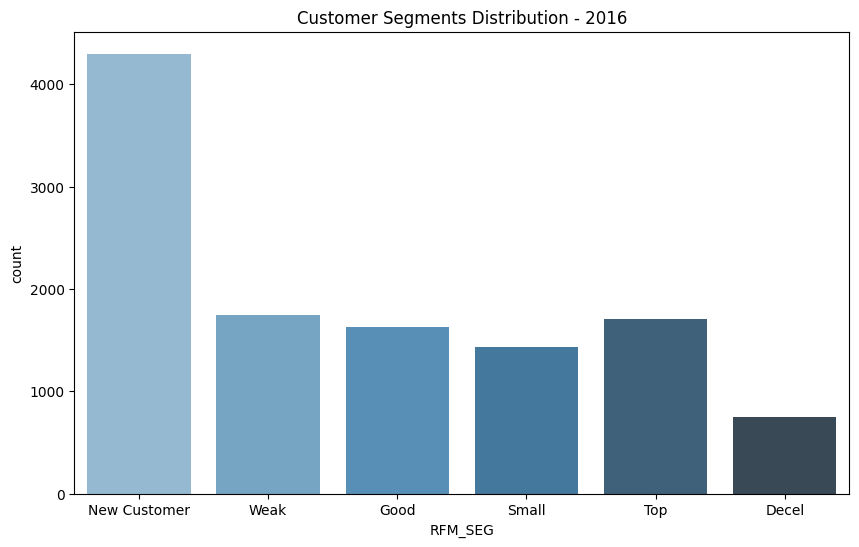

In [261]:
plt.figure(figsize=(10,6))
sns.countplot(data=MASTER_RFM_2016, x='RFM_SEG',palette='Blues_d', order=MASTER_RFM_2015['RFM_SEG'].value_counts().index)
plt.title('Customer Segments Distribution - 2016')

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\3673584393.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='CUMUL_VALUE', palette='Greens_d', order=MASTER_RFM_2015.groupby("RFM_SEG").CUMUL_VALUE.median().sort_values().index)


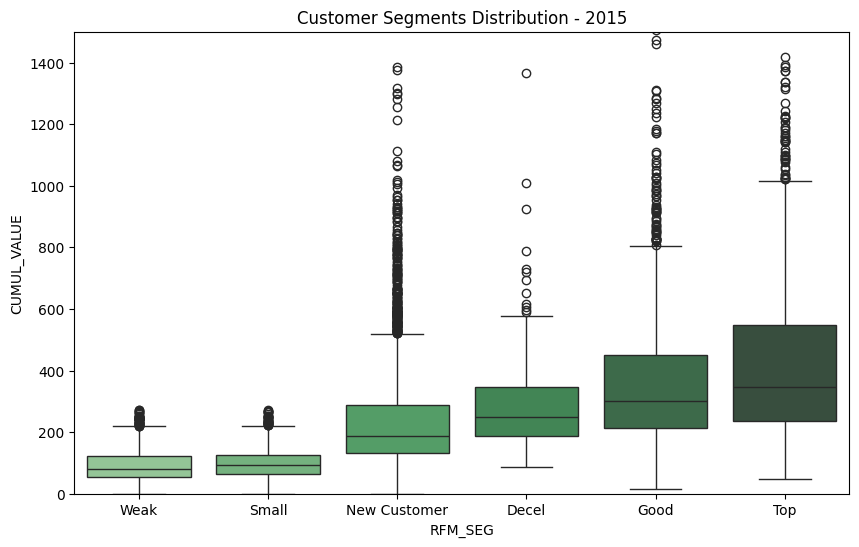

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\3673584393.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='NB_VISITS', palette='Blues_d', order=MASTER_RFM_2015.groupby("RFM_SEG").NB_VISITS.median().sort_values().index)


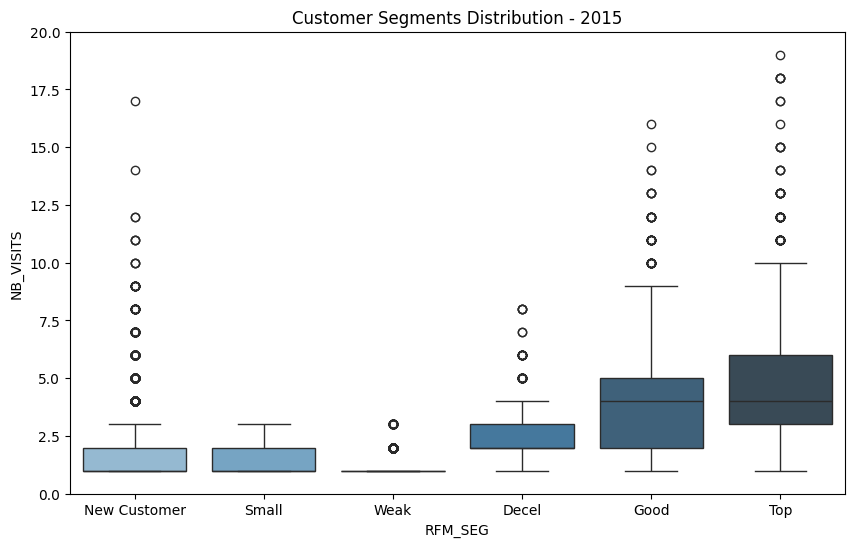

C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\3673584393.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='RECENCY', palette='OrRd', order=MASTER_RFM_2015.groupby("RFM_SEG").RECENCY.median().sort_values(ascending=False).index)


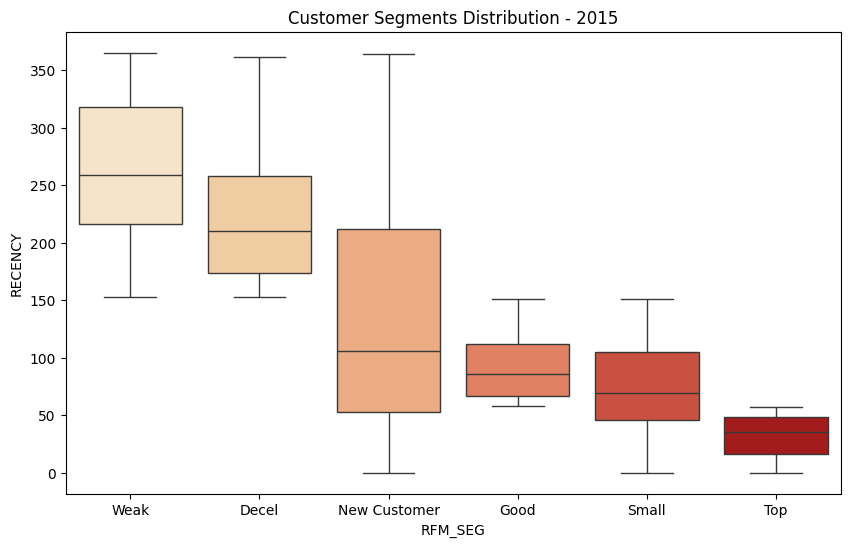

In [273]:
#plot 3 figures
plt.figure(figsize=(10,6))
sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='CUMUL_VALUE', palette='Greens_d', order=MASTER_RFM_2015.groupby("RFM_SEG").CUMUL_VALUE.median().sort_values().index)
plt.ylim(0, 1500)
plt.title('Customer Segments Distribution - 2015')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='NB_VISITS', palette='Blues_d', order=MASTER_RFM_2015.groupby("RFM_SEG").NB_VISITS.median().sort_values().index)
plt.ylim(0, 20)
plt.title('Customer Segments Distribution - 2015')  
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=MASTER_RFM_2015, x='RFM_SEG', y='RECENCY', palette='OrRd', order=MASTER_RFM_2015.groupby("RFM_SEG").RECENCY.median().sort_values(ascending=False).index)
plt.title('Customer Segments Distribution - 2015')  
plt.show()

In [309]:
# Group by RFM_SEG and compute both count and median
total_market_2016 = MASTER_RFM_2016["CUMUL_VALUE"].sum()
rfm_summary_2016 = (
    MASTER_RFM_2016
    .groupby("RFM_SEG")
    .agg(
        nb_individus=("ID_INDIVIDU", "count"),
        median_cumul_value=("CUMUL_VALUE", "median"),
        median_nb_visits=("NB_VISITS", "median"),
        median_recency=("RECENCY", "median"),
        pourcentage_value=("CUMUL_VALUE", lambda x: x.sum() / total_market_2016 * 100)
    )
    .reset_index()
)

rfm_summary_2016


,RFM_SEG,nb_individus,median_cumul_value,median_nb_visits,median_recency,pourcentage_value
0,Decel,751,248.0,2.0,212.0,6.993977
1,Good,1626,304.0,3.0,90.0,20.036162
2,New Customer,4298,201.0,1.0,105.0,35.762769
3,Small,1434,95.0,1.0,69.5,4.880456
4,Top,1704,378.0,4.0,34.0,26.790202
5,Weak,1741,87.0,1.0,246.0,5.536434


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\2280751841.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_summary_2016, x='RFM_SEG', y='pourcentage_value', palette='Blues_d', order=rfm_summary_2016.sort_values('pourcentage_value', ascending=False).RFM_SEG)


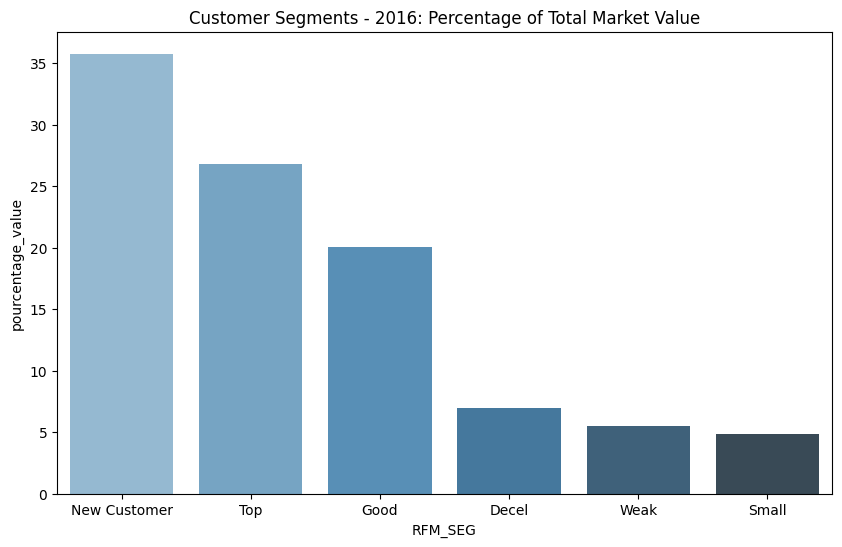

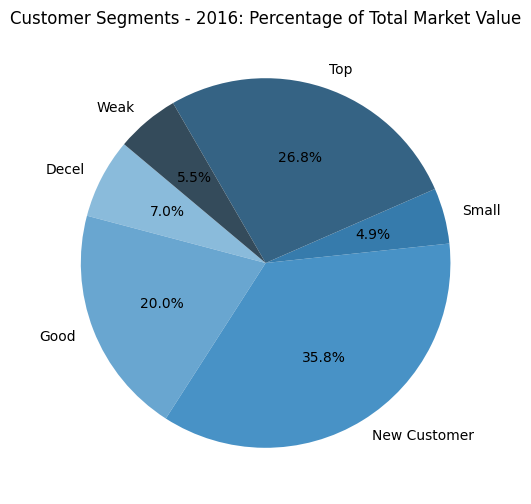

The more important 

In [313]:
# Group by RFM_SEG and compute both count and median
total_market_2015 = MASTER_RFM_2015["CUMUL_VALUE"].sum()
rfm_summary_2015 = (
    MASTER_RFM_2015
    .groupby("RFM_SEG")
    .agg(
        nb_individus=("ID_INDIVIDU", "count"),
        median_cumul_value=("CUMUL_VALUE", "median"),
        median_nb_visits=("NB_VISITS", "median"),
        median_recency=("RECENCY", "median"), 
        pourcentage_value=("CUMUL_VALUE", lambda x: x.sum() / total_market_2015 * 100)
    )
    .reset_index()
)

rfm_summary_2015

,RFM_SEG,nb_individus,median_cumul_value,median_nb_visits,median_recency,pourcentage_value
0,Decel,492,249.5,2.0,210.5,5.987581
1,Good,1380,300.0,4.0,86.0,21.882633
2,New Customer,3808,186.0,1.0,106.0,38.511691
3,Small,1307,92.0,1.0,69.0,5.473594
4,Top,1162,348.0,4.0,35.0,21.840705
5,Weak,1691,79.0,1.0,259.0,6.303796


C:\Users\lucas\AppData\Local\Temp\ipykernel_3732\1343310798.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rfm_summary_2015, x='RFM_SEG', y='pourcentage_value',palette='Blues_d', order=rfm_summary_2015.sort_values('pourcentage_value', ascending=False).RFM_SEG)


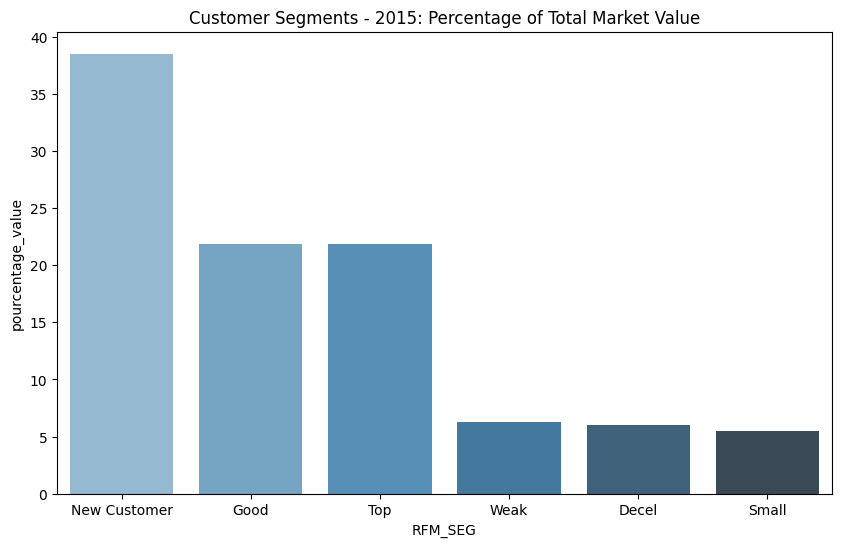

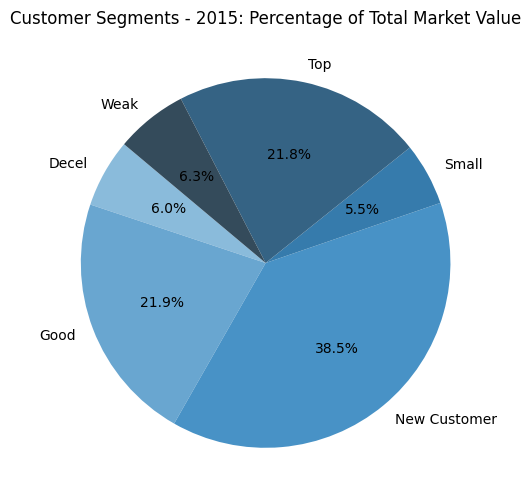

In [314]:
plt.figure(figsize=(10,6))
sns.barplot(data=rfm_summary_2015, x='RFM_SEG', y='pourcentage_value',palette='Blues_d', order=rfm_summary_2015.sort_values('pourcentage_value', ascending=False).RFM_SEG)
plt.title('Customer Segments - 2015: Percentage of Total Market Value')
plt.show()

plt.figure(figsize=(10,6))
#plot pie chart
plt.pie(rfm_summary_2015['pourcentage_value'], labels=rfm_summary_2015['RFM_SEG'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Blues_d', n_colors=len(rfm_summary_2015)))
plt.title('Customer Segments - 2015: Percentage of Total Market Value')
plt.show()

- New customers in 2015 are the main part of the Total Market Value in 2015
- We want to keep them in 2016!
- Bonus: If we focus on retention of top, good and new customers we cover more than **82%** of the Total Market Value in 2016

### Study the migration between 2015 and 2016 segments

- Join both datasets: Keep all the customers of 2015 too see their behavior in 2016 even if they didn't buy anything in 2016

In [324]:
#create MIGRATION_segment_with_NA which is join MASTER_RFM and MASTER_RFM_2016 with NA value takes value "No buyer 2016
MIGRATION_segment_with_NA = MASTER_RFM_2016[["ID_INDIVIDU", "RFM_SEG", "CUMUL_VALUE"]].merge(MASTER_RFM_2015[["ID_INDIVIDU", "RFM_SEG", "CUMUL_VALUE"]], on="ID_INDIVIDU", suffixes=('_2016', '_2015'), how='right')
MIGRATION_segment_with_NA["RFM_SEG_2016"] = MIGRATION_segment_with_NA["RFM_SEG_2016"].fillna("No buyer 2016")
MIGRATION_segment_with_NA["CUMUL_VALUE_2016"] = MIGRATION_segment_with_NA["CUMUL_VALUE_2016"].fillna(0)



In [325]:
MIGRATION_segment_with_NA.head()

,ID_INDIVIDU,RFM_SEG_2016,CUMUL_VALUE_2016,RFM_SEG_2015,CUMUL_VALUE_2015
0,34.0,No buyer 2016,0.0,Good,207.0
1,91.0,Small,112.0,Top,405.0
2,99.0,Good,177.0,Good,173.0
3,449.0,No buyer 2016,0.0,Weak,66.0
4,557.0,Good,272.0,Decel,208.0


In [331]:
pd.crosstab(MIGRATION_segment_with_NA.RFM_SEG_2015, MIGRATION_segment_with_NA.RFM_SEG_2016,margins=True)
## Add % in the crosstab
pd.crosstab(MIGRATION_segment_with_NA.RFM_SEG_2015, MIGRATION_segment_with_NA.RFM_SEG_2016,margins=True)

RFM_SEG_2016,Decel,Good,New Customer,No buyer 2016,Small,Top,Weak,All
RFM_SEG_2015,,,,,,,,
Decel,53,86,0,147,61,80,65,492
Good,100,323,0,253,146,387,171,1380
New Customer,254,505,3,1733,353,454,506,3808
Small,64,153,0,568,184,121,217,1307
Top,94,245,0,157,125,423,118,1162
Weak,77,137,0,951,183,100,243,1691
All,642,1449,3,3809,1052,1565,1320,9840


In [335]:
pd.crosstab(
    MIGRATION_segment_with_NA.RFM_SEG_2015,
    MIGRATION_segment_with_NA.RFM_SEG_2016,
    normalize='index',   # normalize by column
    margins=True
).round(2) * 100



RFM_SEG_2016,Decel,Good,New Customer,No buyer 2016,Small,Top,Weak
RFM_SEG_2015,,,,,,,
Decel,11.0,17.0,0.0,30.0,12.0,16.0,13.0
Good,7.0,23.0,0.0,18.0,11.0,28.0,12.0
New Customer,7.0,13.0,0.0,46.0,9.0,12.0,13.0
Small,5.0,12.0,0.0,43.0,14.0,9.0,17.0
Top,8.0,21.0,0.0,14.0,11.0,36.0,10.0
Weak,5.0,8.0,0.0,56.0,11.0,6.0,14.0
All,7.0,15.0,0.0,39.0,11.0,16.0,13.0


> Note: Almost one half of New Customers in 2015 don't buy in 2016 !!
- 46% of New Customers in 2015 didn't buy in 2016
- 25% of New Customers in 2015 became at least a good Customers in 2016
- 7% of New Customers in 2015 became Decelerated Customers in 2016
- 31% of New Customers in 2015 became small Customers in 2016


It means there is no **RETENTION** !


In [330]:
total_market_new_2015 = MIGRATION_segment_with_NA[MIGRATION_segment_with_NA["RFM_SEG_2015"] == "New Customer"]["CUMUL_VALUE_2015"].sum()
print("Total Market Value in 2015 from New Customers in 2015:", total_market_new_2015)
total_market_new_2015_in_2016 = MIGRATION_segment_with_NA[MIGRATION_segment_with_NA["RFM_SEG_2015"] == "New Customer"]["CUMUL_VALUE_2016"].sum()
print("Total Market Value in 2016 from New Customers in 2015:", total_market_new_2015_in_2016)

Total Market Value in 2015 from New Customers in 2015: 901975.0
Total Market Value in 2016 from New Customers in 2015: 562871.0


This segment represented $901 975$ $ in 2015  and only $562 000$ $ in 2016